<a href="https://colab.research.google.com/github/RonakkudalAI/Practical-Machine-Learning/blob/main/Titanic(Day_7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score, classification_report
sns.load_dataset


<function seaborn.utils.load_dataset(name, cache=True, data_home=None, **kws)>

In [61]:
# df = sns.load_dataset("titanic")
# print(df.head())

df = pd.read_csv("/content/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [62]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [63]:
df.shape

(891, 12)

In [64]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer()

<Axes: xlabel='Survived', ylabel='count'>

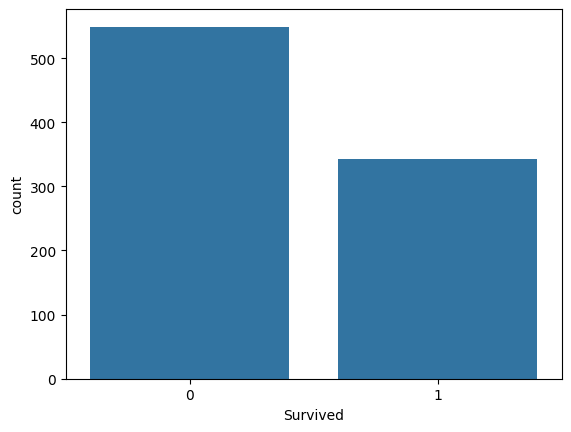

In [65]:
sns.countplot(x='Survived', data=df)

<Axes: xlabel='Survived', ylabel='count'>

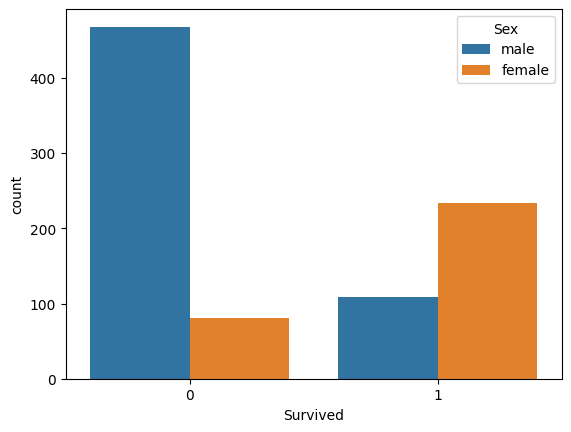

In [66]:
sns.countplot(x = df['Survived'],hue = df['Sex'],data = df)

<Axes: xlabel='Survived', ylabel='count'>

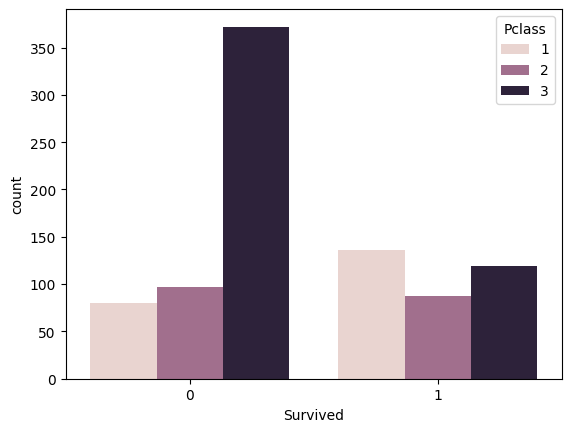

In [67]:
sns.countplot(x = df['Survived'],hue = df['Pclass'],data = df)

<Axes: xlabel='Survived', ylabel='count'>

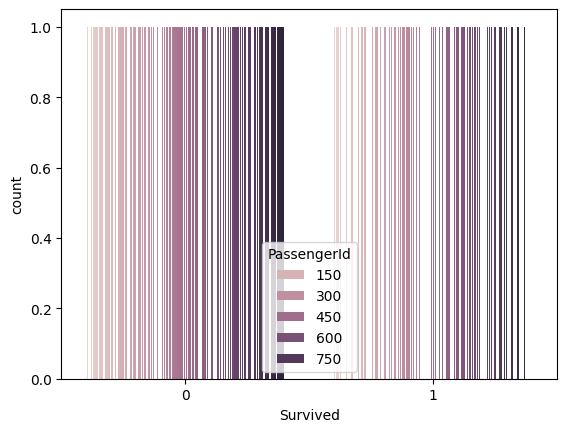

In [68]:
sns.countplot(x = df['Survived'],hue = df['PassengerId'],data = df)

/tmp/ipykernel_21385/3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

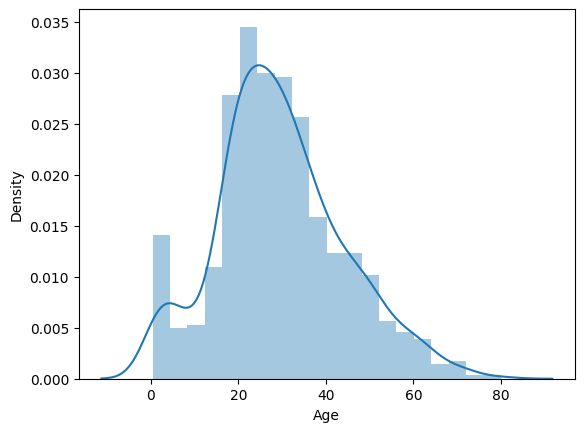

In [69]:
sns.distplot(df['Age'])

<Axes: xlabel='Survived', ylabel='count'>

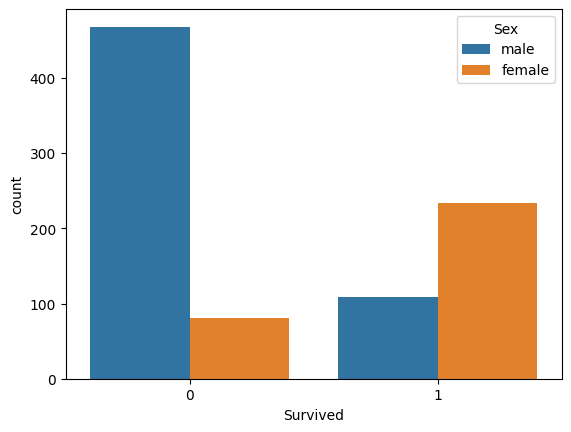

In [70]:
sns.countplot(x = df['Survived'],hue = df['Sex'],data = df)

<Axes: xlabel='Age', ylabel='Count'>

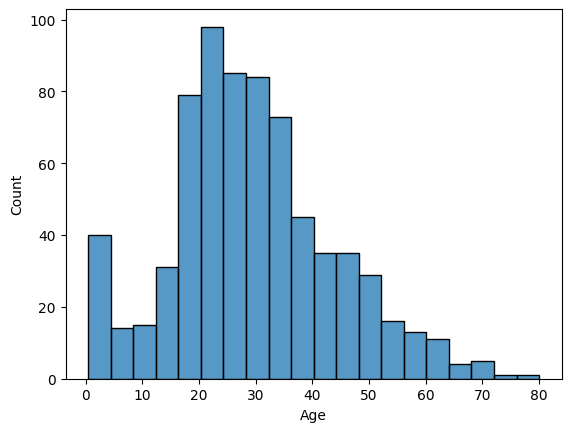

In [71]:
sns.histplot(df['Age'])

<Axes: xlabel='Survived', ylabel='count'>

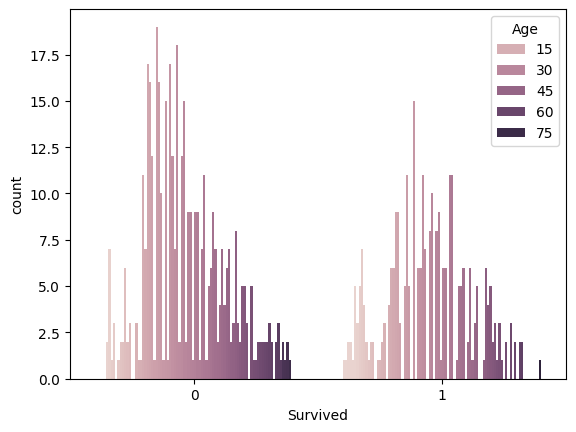

In [72]:
sns.countplot(x=df['Survived'],hue=df['Age'],data= df)

In [73]:
df = df.drop('Cabin',axis = 1)

In [74]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

<Axes: xlabel='Embarked', ylabel='count'>

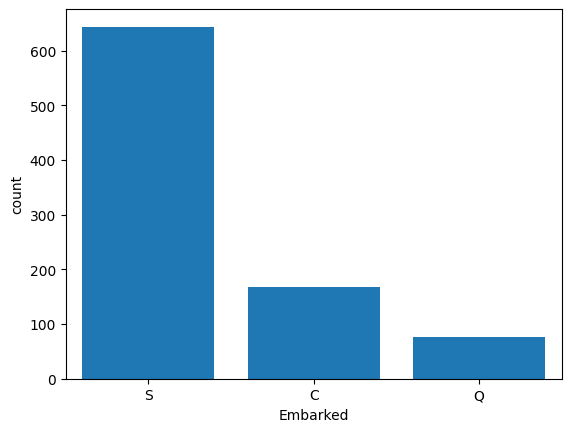

In [75]:
sns.countplot(x = df['Embarked'],hue=[],data= df)

<Axes: >

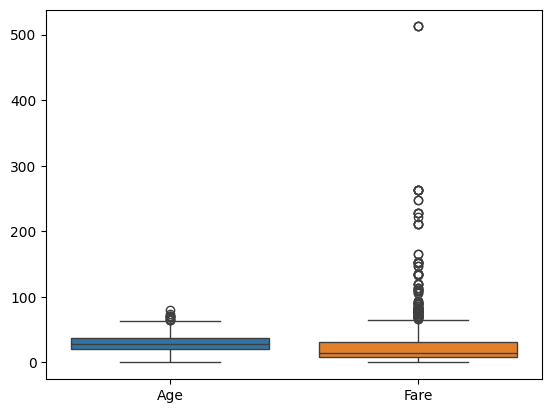

In [76]:
sns.boxplot(data=df[['Age', 'Fare']])

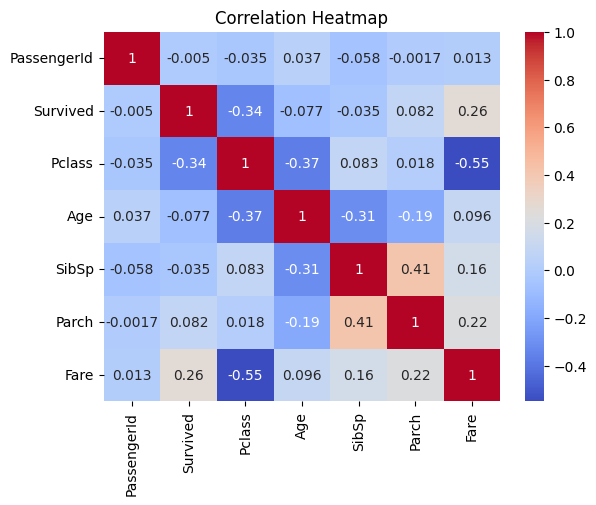

In [77]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [78]:
df = df.drop('PassengerId',axis = 1)

In [79]:
df = df.drop('Name',axis = 1)

In [80]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [81]:
df.drop(['Ticket','SibSp', 'Parch'], axis=1, inplace=True)

In [82]:
df.shape

(891, 6)

In [83]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df['Age'] = imputer.fit_transform(df[['Age']]).ravel()

In [84]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
df['Embarked'] = imputer.fit_transform(df[['Embarked']]).ravel()

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   Fare      891 non-null    float64
 5   Embarked  891 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 41.9+ KB


In [86]:
from sklearn.preprocessing import LabelEncoder
label =LabelEncoder()
df['Sex']  = label.fit_transform(df['Sex'])

In [87]:
label =LabelEncoder()
df['Embarked']  = label.fit_transform(df['Embarked'])

In [88]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,1,22.0,7.2500,2
1,1,1,0,38.0,71.2833,0
2,1,3,0,26.0,7.9250,2
3,1,1,0,35.0,53.1000,2
4,0,3,1,35.0,8.0500,2
...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,2
887,1,1,0,19.0,30.0000,2
888,0,3,0,28.0,23.4500,2
889,1,1,1,26.0,30.0000,0


In [110]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [111]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)


In [112]:
from sklearn.preprocessing import  StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [114]:
y_pred = model.predict(X_test)


In [115]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix


In [116]:
acc = accuracy_score(y_test,y_pred)
acc

0.7988826815642458

In [117]:
cls_r = classification_report(y_test,y_pred)
print(cls_r)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [118]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, metric = 'minkowski',p=2)
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [119]:
y_pred = knn.predict(X_test)

In [120]:
cls_r2 = classification_report(y_test,y_pred)
print(cls_r2)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.72      0.74      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [121]:
# Curve
from sklearn import metrics

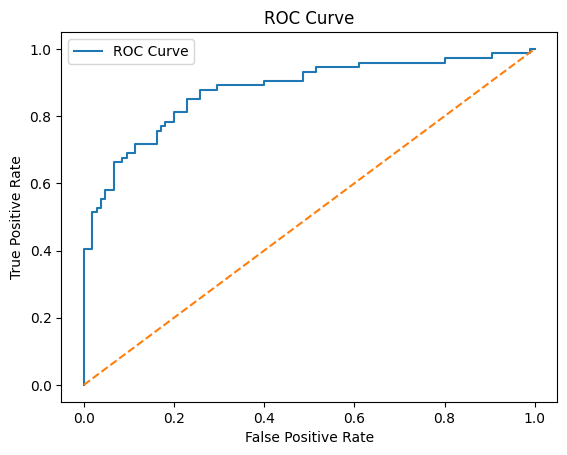

In [122]:
#Get Probabilities
y_pred_proba = model.predict_proba(X_test)[:,1]


# Step 2: ROC values
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

# Step 3: Plot
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()
